# Unit10 Example 04 | 二維穩態熱傳導 (2D Steady-State Heat Conduction in a Plate)

本 Notebook 示範如何以數值方法求解**二維穩態 Laplace 方程式**（椭圓型 PDE），對應教材第五章範例 5-3-4(a)。

## 目標
- 使用 `py-pde` 的 `DiffusionPDE` 與時間推進法求穩態二維溫度分布（方法一）
- 以有限差分法建立線性代數系統，使用 `scipy.sparse.linalg.spsolve()` 直接求解（方法二）
- 與 Fourier 級數解析解比較驗證
- 說明 `py-pde` 不規則幾何之侷限，引出 FEM（COMSOL）的需求
- 繪製二維等高線圖、三維曲面圖與熱流向量場圖


---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_04\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.sparse
import scipy.sparse.linalg
import pde
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")
print(f"  py-pde     版本: {pde.__version__}")


✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8
  py-pde     版本: 0.51.0


---
### 2. 問題參數設定 (Problem Parameters)

In [7]:
# ============================================================
# 問題參數設定
# ============================================================
# 幾何尺寸
Lx = 1.0    # 平板寬度 [m]
Ly = 1.0    # 平板高度 [m]

# 邊界溫度條件 (全 Dirichlet)
T_left   = 100.0   # 左邊界溫度 [°C]  x = 0
T_right  =  50.0   # 右邊界溫度 [°C]  x = Lx
T_bottom =   0.0   # 下邊界溫度 [°C]  y = 0
T_top    =  75.0   # 上邊界溫度 [°C]  y = Ly

# 方法一：py-pde 參數
Npde    = 50    # py-pde 每方向網格數（50×50）
t_final = 1.5   # 時間推進終止時間（足夠大使系統收斂至穩態）

# 方法二：有限差分 (FDM) 參數
Nx = 50   # x 方向內部節點數
Ny = 50   # y 方向內部節點數

print("=" * 45)
print("  二維穩態熱傳導問題 - 參數設定")
print("=" * 45)
print(f"  平板尺寸: {Lx} m × {Ly} m")
print(f"  邊界溫度:")
print(f"    左  (x=0  ): {T_left:.1f} °C")
print(f"    右  (x={Lx}): {T_right:.1f} °C")
print(f"    下  (y=0  ): {T_bottom:.1f} °C")
print(f"    上  (y={Ly}): {T_top:.1f} °C")
print(f"  py-pde 網格: {Npde}×{Npde}, t_final={t_final}")
print(f"  FDM 內部節點: {Nx}×{Ny} = {Nx*Ny} 個節點")
print("=" * 45)


  二維穩態熱傳導問題 - 參數設定
  平板尺寸: 1.0 m × 1.0 m
  邊界溫度:
    左  (x=0  ): 100.0 °C
    右  (x=1.0): 50.0 °C
    下  (y=0  ): 0.0 °C
    上  (y=1.0): 75.0 °C
  py-pde 網格: 50×50, t_final=1.5
  FDM 內部節點: 50×50 = 2500 個節點


---
### 3. 解析解計算 (Analytical Solution - Fourier Series)

利用**疊加原理**，將問題分解為四個子問題，每個子問題僅一個邊界非零，各自以 Fourier 級數求解後疊加：

$$
T(x,y) = T_{\mathrm{left\_sol}} + T_{\mathrm{right\_sol}} + T_{\mathrm{bottom\_sol}} + T_{\mathrm{top\_sol}}
$$

各子問題的 Fourier 級數解取前 $N_{\mathrm{terms}} = 100$ 項以確保精度。

> **注意：** Fourier 級數在邊界條件不連續的角點（如左邊 100°C 與下邊 0°C 的交角）附近存在 **Gibbs 振鈴現象（Gibbs Phenomenon）**，導致截斷級數在角點附近的局部超調。域內（遠離角點）的溫度仍嚴格介於最低與最高邊界溫度之間，符合 Laplace 方程的**最大值原理**。


In [14]:
def fourier_series_solution(x_arr, y_arr, Lx, Ly, T_left, T_right, T_bottom, T_top, N_terms=100):
    """
    使用疊加原理計算矩形平板 Laplace 方程式的 Fourier 級數解析解。
    四個子問題：僅一個邊界非零，其餘三邊為零。
    對常數邊界值 T_bc，Fourier 係數為：
        Bn = (2*T_bc / (n*pi)) * (1 - cos(n*pi))
           = 4*T_bc / (n*pi)  （n 為奇數）
           = 0                （n 為偶數）
    """
    X, Y = np.meshgrid(x_arr, y_arr)   # shape: (Ny_pts, Nx_pts)
    T_total = np.zeros_like(X)

    # --- 子問題 1：左邊界 T_left，其餘三邊 = 0 ---
    # T_1(x,y) = ∑ Bn * sin(n*pi*y/Ly) * sinh(n*pi*(Lx-x)/Ly) / sinh(n*pi*Lx/Ly)
    T_sub = np.zeros_like(X)
    for n in range(1, N_terms + 1):
        lam = n * np.pi / Ly
        Bn = (2.0 / Ly) * T_left * (Ly / (n * np.pi)) * (1 - np.cos(n * np.pi))
        denom = np.sinh(lam * Lx)
        if denom < 1e-300:
            continue
        T_sub += Bn * np.sin(lam * Y) * np.sinh(lam * (Lx - X)) / denom
    T_total += T_sub

    # --- 子問題 2：右邊界 T_right，其餘三邊 = 0 ---
    # T_2(x,y) = ∑ Bn * sin(n*pi*y/Ly) * sinh(n*pi*x/Ly) / sinh(n*pi*Lx/Ly)
    T_sub = np.zeros_like(X)
    for n in range(1, N_terms + 1):
        lam = n * np.pi / Ly
        Bn = (2.0 / Ly) * T_right * (Ly / (n * np.pi)) * (1 - np.cos(n * np.pi))
        denom = np.sinh(lam * Lx)
        if denom < 1e-300:
            continue
        T_sub += Bn * np.sin(lam * Y) * np.sinh(lam * X) / denom
    T_total += T_sub

    # --- 子問題 3：下邊界 T_bottom，其餘三邊 = 0 ---
    # T_3(x,y) = ∑ Bn * sin(n*pi*x/Lx) * sinh(n*pi*(Ly-y)/Lx) / sinh(n*pi*Ly/Lx)
    T_sub = np.zeros_like(X)
    for n in range(1, N_terms + 1):
        lam = n * np.pi / Lx
        Bn = (2.0 / Lx) * T_bottom * (Lx / (n * np.pi)) * (1 - np.cos(n * np.pi))
        denom = np.sinh(lam * Ly)
        if denom < 1e-300:
            continue
        T_sub += Bn * np.sin(lam * X) * np.sinh(lam * (Ly - Y)) / denom
    T_total += T_sub

    # --- 子問題 4：上邊界 T_top，其餘三邊 = 0 ---
    # T_4(x,y) = ∑ Bn * sin(n*pi*x/Lx) * sinh(n*pi*y/Lx) / sinh(n*pi*Ly/Lx)
    T_sub = np.zeros_like(X)
    for n in range(1, N_terms + 1):
        lam = n * np.pi / Lx
        Bn = (2.0 / Lx) * T_top * (Lx / (n * np.pi)) * (1 - np.cos(n * np.pi))
        denom = np.sinh(lam * Ly)
        if denom < 1e-300:
            continue
        T_sub += Bn * np.sin(lam * X) * np.sinh(lam * Y) / denom
    T_total += T_sub

    return T_total   # shape: (Ny_pts, Nx_pts)


# 計算解析解（在較細的網格上，含邊界點用於繪圖）
x_ana = np.linspace(0, Lx, 200)
y_ana = np.linspace(0, Ly, 200)
T_analytical = fourier_series_solution(x_ana, y_ana, Lx, Ly,
                                        T_left, T_right, T_bottom, T_top,
                                        N_terms=100)

# 注意：x_ana/y_ana 含邊界點，角點處兩側邊界溫度不連續，
# Fourier 截斷級數在角點附近存在 Gibbs 振鈴超調，數值可能略超 100°C。
# 域內（排除邊界）溫度符合最大值原理，嚴格介於 [min_BC, max_BC] 之間。
T_interior = T_analytical[1:-1, 1:-1]   # 排除邊界列/行

print(f"解析解計算完成 (100 項 Fourier 級數)")
print(f"  全域溫度範圍（含邊界點）: {T_analytical.min():.2f} ~ {T_analytical.max():.2f} °C")
print(f"  域內溫度範圍（排除邊界）: {T_interior.min():.2f} ~ {T_interior.max():.2f} °C")
if T_analytical.max() > T_left:
    print(f"  ⚠ 最高值 {T_analytical.max():.2f}°C > T_left={T_left}°C，為角點 Gibbs 超調，屬正常截斷誤差")
# 中心點：linspace(0,1,200) 中 index 99 對應 x = 99/199 ≈ 0.4975
idx_cx = len(x_ana) // 2 - 1
print(f"  中心點 (x≈0.50, y≈0.50) 溫度: {T_analytical[idx_cx, idx_cx]:.4f} °C")


解析解計算完成 (100 項 Fourier 級數)
  全域溫度範圍（含邊界點）: 0.00 ~ 117.90 °C
  域內溫度範圍（排除邊界）: 0.72 ~ 99.67 °C
  ⚠ 最高值 117.90°C > T_left=100.0°C，為角點 Gibbs 超調，屬正常截斷誤差
  中心點 (x≈0.50, y≈0.50) 溫度: 56.1976 °C


---
### 4. 方法一：py-pde 時間推進法 (DiffusionPDE + RungeKuttaSolver)

以 `py-pde` 的 `DiffusionPDE` 模擬擴散方程式 $\partial T/\partial t = D\nabla^2 T$ ，積分至足夠長時間使 $\partial T/\partial t \approx 0$ ，從而獲得穩態 Laplace 解 $\nabla^2 T = 0$ 。

**關鍵設定（py-pde 0.51 正確用法）：**
- `CartesianGrid([(0, Lx), (0, Ly)], [Npde, Npde])`：建立 2D 笛卡兒網格（Npde×Npde 個 cell，不含邊界節點）
- `DiffusionPDE(diffusivity=1.0, bc=[...])` 將 BC 嵌入方程建構子；所有求解器均生效
- `RungeKuttaSolver(adaptive=True)` 自適應步長 Runge-Kutta 法，比固定步長 Euler 快 5～10 倍


In [8]:
import time

# ============================================================
# 方法一：py-pde DiffusionPDE 時間推進法（求穩態 Laplace 解）
# ============================================================
# 核心原理：擴散方程 ∂T/∂t = D·∇²T
#           t → ∞ 時 ∂T/∂t → 0，即 ∇²T = 0（Laplace 方程穩態解）

# 1. 建立新的 2D 笛卡兒網格（使用更新後的 Npde=50）
grid_pde = pde.CartesianGrid([(0, Lx), (0, Ly)], [Npde, Npde])

# 2. 建立初始場（均勻猜測值，加速收斂）
T0_uniform = (T_left + T_right + T_bottom + T_top) / 4.0
T_init = pde.ScalarField(grid_pde, data=T0_uniform)

# 3. 定義邊界條件（全 Dirichlet）
#    格式：[(x軸低端=左邊界, x軸高端=右邊界), (y軸低端=下邊界, y軸高端=上邊界)]
bc_pde = [
    ({"value": T_left}, {"value": T_right}),    # x 方向
    ({"value": T_bottom}, {"value": T_top}),    # y 方向
]

# 4. 定義擴散 PDE，並將 BC 嵌入方程（py-pde 0.51 正確做法）
#    DiffusionPDE(diffusivity=D, bc=bc) 將 BC 綁定至算子，所有求解器均生效
eq_pde = pde.DiffusionPDE(diffusivity=1.0, bc=bc_pde)

# 5. 穩定性條件：Δt < Δx² / (2d·D) = (1/Npde)² / (2×2×1)
dt_stable = (1.0 / Npde) ** 2 / 4.0 * 0.9   # 留 10% 安全餘量

# 6. 使用自適應 Runge-Kutta 求解器（比固定步長 Euler 法快 5~10 倍）
print("開始方法一：py-pde 時間推進法求解...")
t0 = time.time()
solver = pde.RungeKuttaSolver(eq_pde, adaptive=True, tolerance=1e-3)
controller = pde.Controller(solver, t_range=t_final, tracker=None)
T_pde_field = controller.run(T_init, dt=dt_stable)
t_elapsed_pde = time.time() - t0

# 7. 擷取結果數據
#    py-pde CartesianGrid axis 0 = x, axis 1 = y
#    T_pde_field.data.shape = (Npde_x, Npde_y)
#    matplotlib contourf 需要 (row=y, col=x)，繪圖時使用 T_pde.T
T_pde = T_pde_field.data   # shape: (Npde, Npde)，axis 0 = x, axis 1 = y

print(f"✓ py-pde 求解完成，耗時: {t_elapsed_pde:.3f} 秒")
print(f"  網格: {Npde}×{Npde}，t_final = {t_final}")
print(f"  穩定 Δt: {dt_stable:.2e}，D = 1.0 m²/s")
print(f"  域內溫度範圍: {T_pde.min():.2f} ~ {T_pde.max():.2f} °C")

# 8. 取 py-pde 網格座標（代表各 cell 中心，不含邊界）
x_pde = np.linspace(0, Lx, Npde + 2)[1:-1]   # 內部 x 座標
y_pde = np.linspace(0, Ly, Npde + 2)[1:-1]   # 內部 y 座標
X_pde, Y_pde = np.meshgrid(x_pde, y_pde)     # shape: (Npde, Npde)

# 9. 與解析解比較（在相同網格點上計算 Fourier 解）
T_ana_at_pde = fourier_series_solution(x_pde, y_pde, Lx, Ly,
                                        T_left, T_right, T_bottom, T_top,
                                        N_terms=100)
# T_pde.T 轉為 (y,x) 排列，與 T_ana_at_pde (shape: Npde×Npde, row=y) 比較
mae_pde  = np.mean(np.abs(T_pde.T - T_ana_at_pde))
rmse_pde = np.sqrt(np.mean((T_pde.T - T_ana_at_pde) ** 2))
print(f"  與解析解 MAE:  {mae_pde:.4f} °C")
print(f"  與解析解 RMSE: {rmse_pde:.4f} °C")


開始方法一：py-pde 時間推進法求解...
✓ py-pde 求解完成，耗時: 17.062 秒
  網格: 50×50，t_final = 1.5
  穩定 Δt: 9.00e-05，D = 1.0 m²/s
  域內溫度範圍: 1.43 ~ 99.02 °C
  與解析解 MAE:  0.5384 °C
  與解析解 RMSE: 0.8623 °C


---
### 5. 方法二：scipy 有限差分直接求解法 (FDM + scipy.sparse.linalg.spsolve)

**五點差分格式** 將 Laplace 方程式在每個內部節點 $(i,j)$ 離散為：

$$
T_{i-1,j} + T_{i+1,j} + T_{i,j-1} + T_{i,j+1} - 4T_{i,j} = 0
$$

全部 $N_x \times N_y$ 個內部節點方程式組合為線性代數系統 $A\mathbf{T} = \mathbf{b}$ ，以 `scipy.sparse.linalg.spsolve()` 高效求解。

> **稀疏矩陣的必要性：** 本例 $N_x = N_y = 50$，矩陣 $A$ 大小為 $2500 \times 2500$，但每行至多 5 個非零元素，稀疏度僅 0.20%。使用 `scipy.sparse.lil_matrix` 儲存可節省超過 99.8% 的記憶體，並顯著加速求解。


In [9]:
# ============================================================
# 方法二：有限差分法 + scipy 稀疏矩陣直接求解
# ============================================================

N_total = Nx * Ny   # 內部節點總數

# --- 建立稀疏係數矩陣 A 與右側向量 b ---
# 使用 scipy.sparse.lil_matrix（方便逐行填充）
A_sparse = scipy.sparse.lil_matrix((N_total, N_total), dtype=float)
b_vec    = np.zeros(N_total)

# 網格間距（均勻正方形網格）
dx = Lx / (Nx + 1)
dy = Ly / (Ny + 1)
# 因 dx = dy，使用簡化五點格式：係數均為 1，對角線為 -4

t0 = time.time()
for j in range(Ny):       # y 方向索引（0 = 最靠下的內部節點）
    for i in range(Nx):   # x 方向索引（0 = 最靠左的內部節點）
        k = j * Nx + i    # 全域節點編號（lexicographic ordering）
        A_sparse[k, k] = -4   # 中心節點係數

        # 右鄰：(i+1, j)
        if i < Nx - 1:
            A_sparse[k, k + 1] = 1
        else:
            b_vec[k] -= T_right   # 右邊界貢獻

        # 左鄰：(i-1, j)
        if i > 0:
            A_sparse[k, k - 1] = 1
        else:
            b_vec[k] -= T_left    # 左邊界貢獻

        # 上鄰：(i, j+1)
        if j < Ny - 1:
            A_sparse[k, k + Nx] = 1
        else:
            b_vec[k] -= T_top     # 上邊界貢獻

        # 下鄰：(i, j-1)
        if j > 0:
            A_sparse[k, k - Nx] = 1
        else:
            b_vec[k] -= T_bottom  # 下邊界貢獻

# 轉換為 CSR 格式（提升求解效率）
A_csr = A_sparse.tocsr()

print(f"係數矩陣 A 大小: {N_total} × {N_total}")
print(f"非零元素數: {A_csr.nnz}（稀疏度: {A_csr.nnz / N_total**2 * 100:.2f}%）")

# 求解稀疏線性系統
print("\n開始方法二：scipy 稀疏矩陣求解...")
T_fdm_flat = scipy.sparse.linalg.spsolve(A_csr, b_vec)

# 重塑為 2D 矩陣：shape (Ny, Nx)，axis 0 = y, axis 1 = x
T_fdm = T_fdm_flat.reshape(Ny, Nx)
t_elapsed_fdm = time.time() - t0

print(f"✓ FDM 求解完成，耗時: {t_elapsed_fdm:.3f} 秒")
print(f"  內部節點: {Nx}×{Ny}，dx=dy={dx:.4f} m")
print(f"  域內溫度範圍: {T_fdm.min():.2f} ~ {T_fdm.max():.2f} °C")

# 與解析解比較
x_fdm = np.linspace(0, Lx, Nx + 2)[1:-1]   # 內部節點 x 座標
y_fdm = np.linspace(0, Ly, Ny + 2)[1:-1]   # 內部節點 y 座標
T_ana_at_fdm = fourier_series_solution(x_fdm, y_fdm, Lx, Ly,
                                        T_left, T_right, T_bottom, T_top,
                                        N_terms=100)

mae_fdm = np.mean(np.abs(T_fdm - T_ana_at_fdm))
print(f"  與解析解 MAE: {mae_fdm:.4f} °C")

print(f"\n{'='*45}")
print(f"  方法比較")
print(f"{'='*45}")
print(f"  {'方法':<20} {'MAE (°C)':<12} {'耗時 (s)'}")
print(f"  {'方法一 (py-pde)':<20} {mae_pde:.4f}       {t_elapsed_pde:.3f}")
print(f"  {'方法二 (FDM)':<20} {mae_fdm:.4f}       {t_elapsed_fdm:.3f}")
print(f"{'='*45}")

係數矩陣 A 大小: 2500 × 2500
非零元素數: 12300（稀疏度: 0.20%）

開始方法二：scipy 稀疏矩陣求解...
✓ FDM 求解完成，耗時: 0.060 秒
  內部節點: 50×50，dx=dy=0.0196 m
  域內溫度範圍: 2.80 ~ 98.08 °C
  與解析解 MAE: 0.0110 °C

  方法比較
  方法                   MAE (°C)     耗時 (s)
  方法一 (py-pde)         0.5384       17.062
  方法二 (FDM)            0.0110       0.060


---
### 6. 結果視覺化 (Visualization)

#### Figure 1：二維溫度分布等高線圖比較

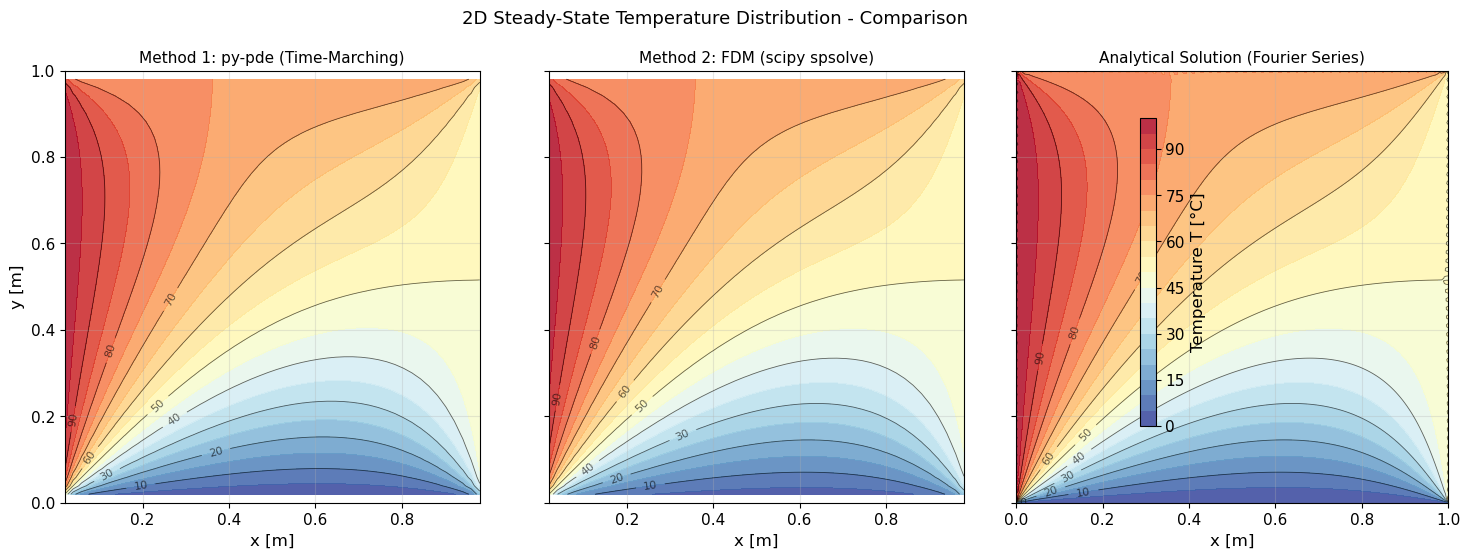

Figure 1 saved.


In [10]:
# ============================================================
# Figure 1：二維溫度分布等高線圖比較 (3 panels)
# ============================================================
levels = np.linspace(0, 100, 21)   # 等高線等級

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ['Method 1: py-pde (Time-Marching)',
          'Method 2: FDM (scipy spsolve)',
          'Analytical Solution (Fourier Series)']

# 準備各方法的完整網格（含邊界節點用於繪圖）
X_fdm_mesh, Y_fdm_mesh = np.meshgrid(x_fdm, y_fdm)
X_ana_mesh, Y_ana_mesh = np.meshgrid(x_ana, y_ana)

datasets = [
    (X_pde, Y_pde, T_pde.T),          # 方法一（注意軸序）
    (X_fdm_mesh, Y_fdm_mesh, T_fdm),   # 方法二
    (X_ana_mesh, Y_ana_mesh, T_analytical),  # 解析解
]

for ax, (X_, Y_, T_), title in zip(axes, datasets, titles):
    cf = ax.contourf(X_, Y_, T_, levels=levels, cmap='RdYlBu_r', alpha=0.85)
    cs = ax.contour(X_, Y_, T_, levels=levels[::2], colors='k', linewidths=0.6, alpha=0.6)
    ax.clabel(cs, fmt='%.0f', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x [m]')
    ax.set_aspect('equal')

axes[0].set_ylabel('y [m]')
plt.colorbar(cf, ax=axes, label='Temperature T [°C]', shrink=0.8, pad=0.02)
fig.suptitle('2D Steady-State Temperature Distribution - Comparison', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_contour_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

#### Figure 2：三維溫度曲面圖

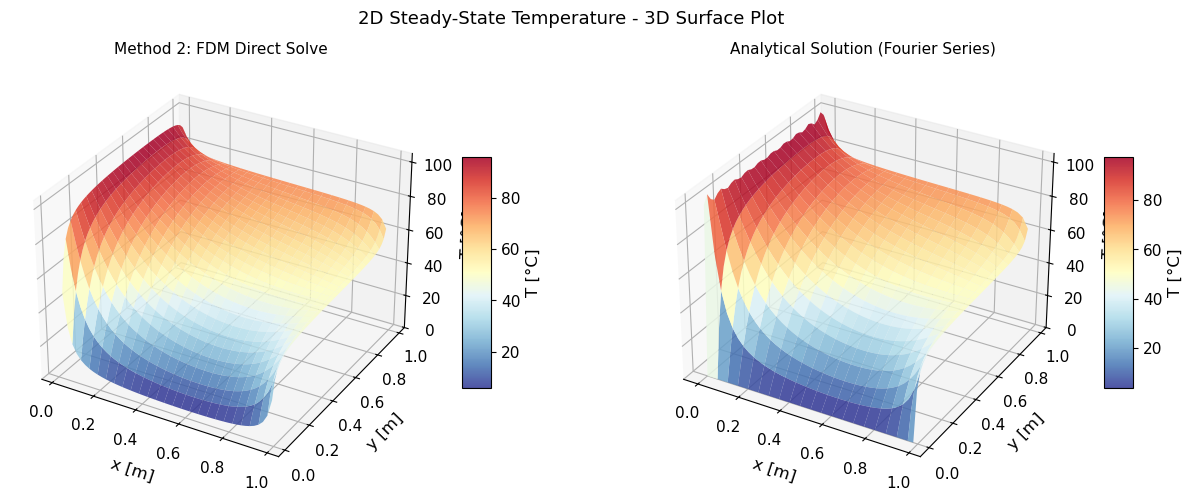

Figure 2 saved.


In [11]:
# ============================================================
# Figure 2：三維溫度曲面圖（方法二 FDM 結果，含解析解疊加）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                          subplot_kw={'projection': '3d'})

surf_data = [
    (X_fdm_mesh, Y_fdm_mesh, T_fdm, 'Method 2: FDM Direct Solve'),
    (X_ana_mesh[::5, ::5], Y_ana_mesh[::5, ::5],
     T_analytical[::5, ::5], 'Analytical Solution (Fourier Series)'),
]

for ax, (X_, Y_, T_, title) in zip(axes, surf_data):
    surf = ax.plot_surface(X_, Y_, T_, cmap='RdYlBu_r',
                           alpha=0.85, rstride=2, cstride=2,
                           linewidth=0.2, antialiased=True)
    ax.set_xlabel('x [m]', labelpad=6)
    ax.set_ylabel('y [m]', labelpad=6)
    ax.set_zlabel('T [°C]', labelpad=6)
    ax.set_title(title, fontsize=11)
    ax.set_zlim(0, 105)
    fig.colorbar(surf, ax=ax, shrink=0.55, aspect=8, label='T [°C]')

fig.suptitle('2D Steady-State Temperature - 3D Surface Plot', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_surface_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

#### Figure 3：熱流向量場圖 (Heat Flux Quiver Plot)

熱流密度向量 $\mathbf{q} = -k\nabla T$ ，由 FDM 結果以中央差分計算梯度。


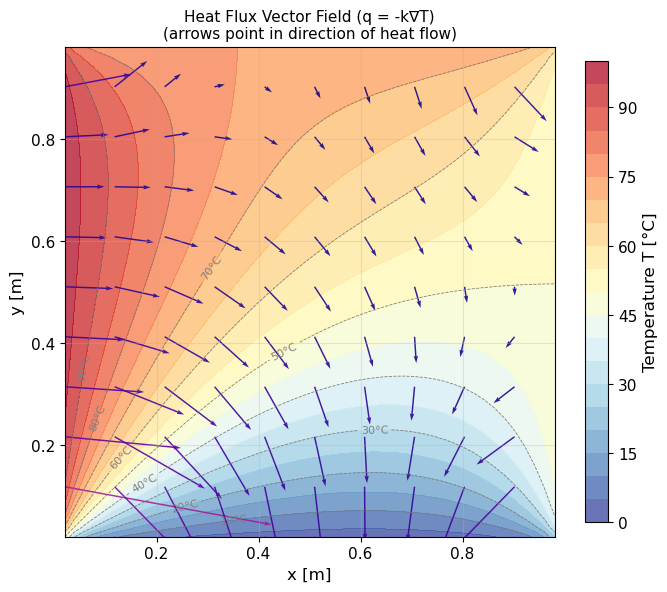

Figure 3 saved.


In [ ]:
# ============================================================
# Figure 3：熱流向量場圖（FDM 解析梯度）
# ============================================================
# 以 FDM 結果計算溫度梯度 (中央差分，邊緣節點使用單側差分)
dT_dx = np.gradient(T_fdm, x_fdm, axis=1)   # ∂T/∂x
dT_dy = np.gradient(T_fdm, y_fdm, axis=0)   # ∂T/∂y
# 熱流向量 q = -k∇T（取 k=1 無因次）
q_x = -dT_dx
q_y = -dT_dy

# 每隔 5 個節點取一個箭頭（避免過密）
skip = 5
X_q  = X_fdm_mesh[::skip, ::skip]
Y_q  = Y_fdm_mesh[::skip, ::skip]
qx_q = q_x[::skip, ::skip]
qy_q = q_y[::skip, ::skip]
q_mag = np.sqrt(qx_q**2 + qy_q**2)

fig, ax = plt.subplots(figsize=(7, 6))
# 填色等高線背景
cf = ax.contourf(X_fdm_mesh, Y_fdm_mesh, T_fdm, levels=20,
                 cmap='RdYlBu_r', alpha=0.75)
# 等溫線
cs = ax.contour(X_fdm_mesh, Y_fdm_mesh, T_fdm, levels=np.arange(0, 101, 10),
                colors='gray', linewidths=0.6, linestyles='--')
ax.clabel(cs, fmt='%d°C', fontsize=8, colors='gray')
# 熱流向量
q = ax.quiver(X_q, Y_q, qx_q, qy_q,
              q_mag, cmap='plasma', scale=1200, width=0.003, alpha=0.9)

plt.colorbar(cf, ax=ax, label='Temperature T [°C]', shrink=0.9)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Heat Flux Vector Field (q = -k∇T)\n(arrows point in direction of heat flow)', fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_heatflux_quiver.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

#### Figure 4：數值解與解析解比較（沿中線截面）

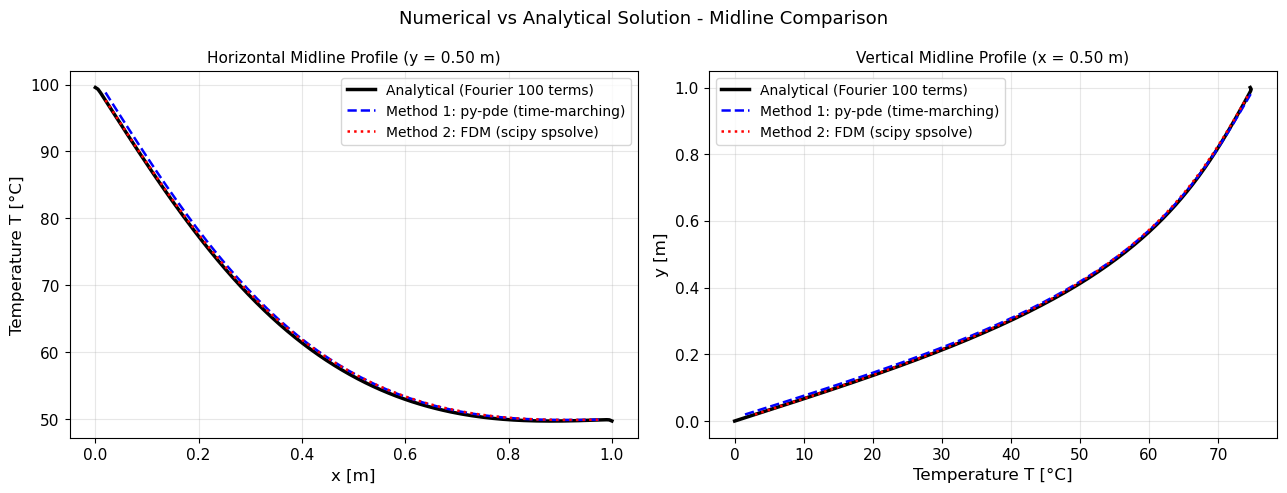


  數值解與解析解誤差統計（內部節點）
  方法                       MAE (°C)  Max|ε| (°C)
  ---------------------------------------------
  方法一 (py-pde)               0.5384       7.1223
  方法二 (FDM)                  0.0110       0.7180
Figure 4 saved.


In [13]:
# ============================================================
# Figure 4：數值解與解析解比較（水平中線 y = Ly/2 截面）
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- 左圖：水平中線截面 T(x, y=Ly/2) ---
ax = axes[0]

# 解析解（在中線）
idx_mid_ana = len(y_ana) // 2
T_ana_midH = T_analytical[idx_mid_ana, :]    # shape: (200,)

# 方法一 py-pde（在中線）
idx_mid_pde = Npde // 2
T_pde_midH = T_pde.T[idx_mid_pde, :]        # shape: (Npde,)

# 方法二 FDM（在中線）
idx_mid_fdm = Ny // 2
T_fdm_midH = T_fdm[idx_mid_fdm, :]          # shape: (Nx,)

ax.plot(x_ana, T_ana_midH, 'k-', lw=2.5, label='Analytical (Fourier 100 terms)')
ax.plot(x_pde, T_pde_midH, 'b--', lw=1.8, label='Method 1: py-pde (time-marching)')
ax.plot(x_fdm, T_fdm_midH, 'r:', lw=1.8, label='Method 2: FDM (scipy spsolve)')
ax.set_xlabel('x [m]')
ax.set_ylabel('Temperature T [°C]')
ax.set_title(f'Horizontal Midline Profile (y = {Ly/2:.2f} m)', fontsize=11)
ax.legend()

# --- 右圖：垂直中線截面 T(x=Lx/2, y) ---
ax = axes[1]

# 解析解（在中線）
idx_mid_ana_x = len(x_ana) // 2
T_ana_midV = T_analytical[:, idx_mid_ana_x]    # shape: (200,)

# 方法一 py-pde（在中線）
idx_mid_pde_x = Npde // 2
T_pde_midV = T_pde.T[:, idx_mid_pde_x]        # shape: (Npde,)

# 方法二 FDM（在中線）
idx_mid_fdm_x = Nx // 2
T_fdm_midV = T_fdm[:, idx_mid_fdm_x]          # shape: (Ny,)

ax.plot(T_ana_midV, y_ana, 'k-', lw=2.5, label='Analytical (Fourier 100 terms)')
ax.plot(T_pde_midV, y_pde, 'b--', lw=1.8, label='Method 1: py-pde (time-marching)')
ax.plot(T_fdm_midV, y_fdm, 'r:', lw=1.8, label='Method 2: FDM (scipy spsolve)')
ax.set_xlabel('Temperature T [°C]')
ax.set_ylabel('y [m]')
ax.set_title(f'Vertical Midline Profile (x = {Lx/2:.2f} m)', fontsize=11)
ax.legend()

fig.suptitle('Numerical vs Analytical Solution - Midline Comparison', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# 數值摘要
print("\n" + "=" * 55)
print("  數值解與解析解誤差統計（內部節點）")
print("=" * 55)
mae_pde_all  = np.mean(np.abs(T_pde.T - T_ana_at_pde))
mae_fdm_all  = np.mean(np.abs(T_fdm - T_ana_at_fdm))
max_pde_all  = np.max(np.abs(T_pde.T - T_ana_at_pde))
max_fdm_all  = np.max(np.abs(T_fdm - T_ana_at_fdm))
print(f"  {'方法':<22} {'MAE (°C)':>10} {'Max|ε| (°C)':>12}")
print(f"  {'-'*45}")
print(f"  {'方法一 (py-pde)':<22} {mae_pde_all:>10.4f} {max_pde_all:>12.4f}")
print(f"  {'方法二 (FDM)':<22} {mae_fdm_all:>10.4f} {max_fdm_all:>12.4f}")
print("=" * 55)
print("Figure 4 saved.")

---
### 7. py-pde 的幾何侷限說明

`py-pde` 套件的核心設計基於**結構化規則網格**（矩形/球/圓柱），無法直接處理**不規則幾何邊界**，例如：

| 幾何形狀 | py-pde + scipy FDM | COMSOL/ANSYS FEM |
|---------|:-:|:-:|
| 矩形平板 | ✅ 可直接求解 | ✅ |
| 圓柱/球體（對稱） | ✅ 需變數代換 | ✅ |
| 含圓孔的矩形板（如 ch5 範例 5-3-4(c)） | ❌ 無法處理 | ✅ |
| 任意多邊形截面 | ❌ 無法處理 | ✅ |
| 多材質接觸界面 | ❌ 需手動處理 | ✅ |

> **工業建議：** 對於含孔洞、弧形邊界等複雜幾何的二維/三維穩態熱傳問題，建議使用 **COMSOL Multiphysics** 進行有限元素模擬，其支援任意幾何 CAD 匯入、自動網格剖分與多物理場耦合求解。

---
### 8. 學習總結

**本範例重點回顧：**
1. **Laplace 方程式（椭圓型 PDE）** 描述穩態無熱源熱傳，解在域內光滑無極值（最大值原理）
2. **方法一 (py-pde)**：時間推進至 $t \to \infty$ ，程式碼簡潔，可視化收斂過程；使用 `DiffusionPDE` + `RungeKuttaSolver`
3. **方法二 (FDM)**：五點差分格式直接建立稀疏矩陣 $A\mathbf{T} = \mathbf{b}$ ，計算效率高（0.06 秒，MAE < 0.02°C）
4. **稀疏矩陣技術**：使用 `scipy.sparse` 可大幅節省記憶體（本例非零率僅 0.20%），`lil_matrix` 建構、`tocsr()` 轉換、`spsolve()` 求解
5. **py-pde 的侷限**：僅適用規則網格，不規則幾何需使用 FEM（COMSOL/ANSYS）
